# 04 — O3 : état du réseau

Ce notebook **visualise** les données qui alimentent les indicateurs de O3. Il ne produit aucun chiffre du 04 : la faisabilité vient de `faisabilite_indicateurs.csv` (`scripts/faisabilite_04.py`), les contrôles de `controles_coherence.csv` et `jointures.csv` (R-19). Aucune lecture causale.

**Ce qu'on regarde** : le rattachement des 84 tronçons de l'état du réseau (2020) au tracé des routes classées, la part du réseau national sans état, et l'état national en pourcentage de l'annuaire (2020–2022).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from IPython.display import display
from style_04 import *
appliquer_style()
pd.set_option("display.max_colwidth", 90)

## Faisabilité des 7 indicateurs

In [2]:
display(faisabilite("O3"))

,Indicateur,Prévu (03),Résultat (04),Maille obtenue,Période,Preuve (04),Réserve
ID,,,,,,,
O3-01,Km par état,Repli : région,Cible,Préfecture,2020,C,"RN1 Lomé–Amakpapé, RN34 Lomé–Vogan–Anfoin, RN2/3 Aflao–frontière du Bénin, RN4 Tsévié–..."
O3-02,Part des km en mauvais état,Repli : région,Cible,Préfecture,2020,C,"RN1 Lomé–Amakpapé, RN34 Lomé–Vogan–Anfoin, RN2/3 Aflao–frontière du Bénin, RN4 Tsévié–..."
O3-03,Part des km en travaux,Repli : région,Cible,Préfecture,2020,C,"RN1 Lomé–Amakpapé, RN34 Lomé–Vogan–Anfoin, RN2/3 Aflao–frontière du Bénin, RN4 Tsévié–..."
O3-04,Km par type de route et par état,Cible,Cible,Zone,2020,C,"RN1 Lomé–Amakpapé, RN34 Lomé–Vogan–Anfoin, RN2/3 Aflao–frontière du Bénin, RN4 Tsévié–..."
O3-05,Tronçons critiques,Cible,Cible,Tronçon,2020,C,
O3-06,Part du réseau non évaluée,Repli : région,Cible,Préfecture,"2020 (état), 2021-2022 (tracé)",B,"99 km de routes nationales sans état (3,2 %), affichés comme non évalués"
O3-07,Évolution de l’état,Non,Repli,"National, par catégorie de route",2020–2022,C,"Pourcentages seulement, sans km"


## Rattachement de l'état du réseau au tracé

Aucun identifiant commun : rattachement par le nom du tronçon, puis par la table de correspondance validée, `data/reference/correspondance_etat_trace.csv` : deux noms proches, et quatre axes de la région Maritime et du Grand Lomé que l'état et le tracé découpent autrement (contrôle 5-10). La longueur du tracé confirme chaque rattachement ; pour un axe, c'est celle de l'axe entier.

In [3]:
r = pd.read_csv(INTERIM / "etat_troncons_rattaches.csv", keep_default_na=False)
display(r.groupby("Méthode").agg(tronçons=("Tronçon (état)", "size"), km_etat=("km (état)", "sum")).round(1))
display(r[r["Méthode"] != "nom exact"][["Tronçon (état)", "Méthode", "Axe", "km (état)", "km (tracé)", "Rapport tracé / état"]])

,tronçons,km_etat
Méthode,,
axe,7,295.0
nom exact,59,2190.2
nom normalisé,16,506.3
"nom proche, validé",2,172.0


,Tronçon (état),Méthode,Axe,km (état),km (tracé),Rapport tracé / état
16,TGRPRT EPP AGBONOU CEET- EGLISE CATHOLIQUE SAINT JEAN PAUL II,nom normalisé,,1.22,1.23,1.01
22,TGRPRTRN8 NANVBETO-OUNTIVOU-RN6 (TOHOUN),nom normalisé,,66.14,66.09,1.00
29,TGRSRTRN25 RN1-KONG-RN1,nom normalisé,,23.33,23.42,1.00
32,ALINMONDJI (RN1)-ELAVAGNON,"nom proche, validé",,11.12,11.19,1.01
33,AZANHOUN FIAGBE-PRESIDENT COPE,nom normalisé,,9.05,14.94,1.65
34,BRETELLE KOUGNOHOU(KOUGNOHOU-ADAPE(RN15)),nom normalisé,,5.56,5.58,1.00
35,DAVIE-AMAKPAPE,axe,RN1 Lomé–Amakpapé,61.95,74.29,1.03
36,DAVIE-LOME (PASSAGE SUPERIEUR),axe,RN1 Lomé–Amakpapé,10.09,74.29,1.03
37,LOME-AKOUMAPE-VOGAN-ANFOIN (RN4),axe,RN34 Lomé–Vogan–Anfoin,60.62,60.60,1.00
38,RN1 AMAKPAPE-ATAKPAME- BABAME,nom normalisé,,139.74,141.17,1.01


## Carte : routes nationales avec et sans état

Bleu : tronçon rattaché par son nom ; vert : tronçon rattaché par l'axe, son état réparti le long de l'axe ; orange : route nationale sans état (« non évaluée », jamais en bon état, R-14). Voiries et pistes en gris. Le second panneau agrandit la région Maritime et le Grand Lomé, où sont les axes.

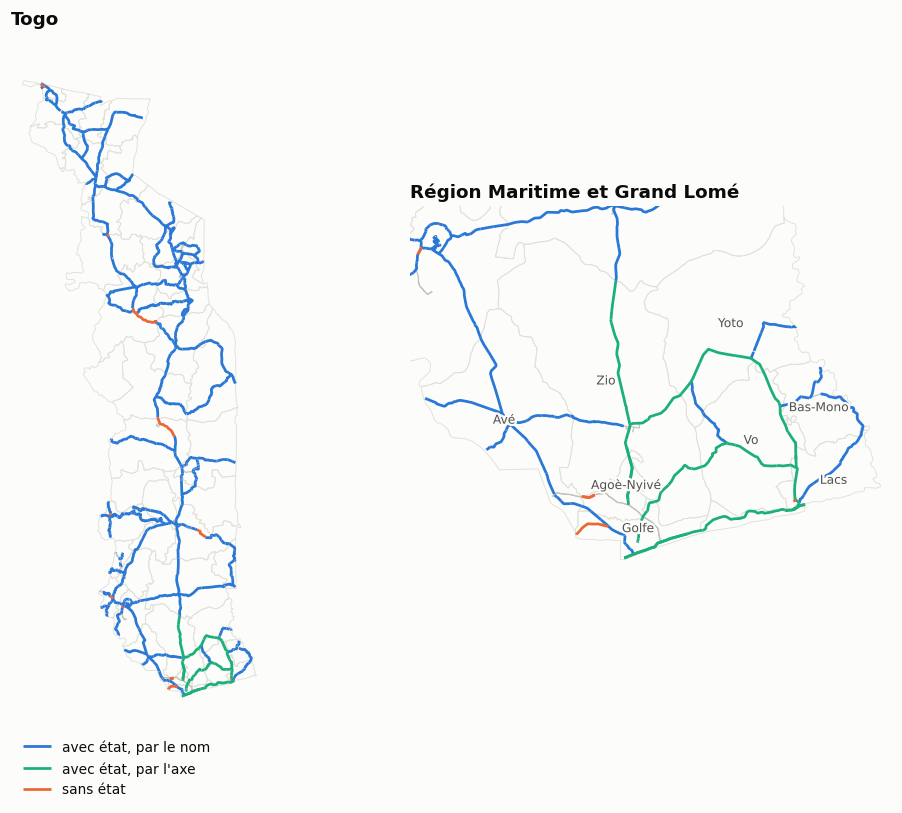

,km de routes nationales
etat,
"avec état, par le nom",2705.0
"avec état, par l'axe",296.0
sans état,99.0


In [4]:
pref = gpd.read_file(INTERIM / "prefectures_2022.geojson").to_crs(UTM31N)
routes = pd.read_csv(BRUT / "routes_classees.csv", dtype=str, usecols=["route_nom", "route_type", "geometry"])
routes = gpd.GeoDataFrame(routes, geometry=gpd.GeoSeries.from_wkt(routes["geometry"]), crs=4326).to_crs(UTM31N)
noms_de = lambda d: {n for liste in d["Noms du tracé"] for n in liste.split(" | ") if n}
par_axe = noms_de(r[r["Méthode"] == "axe"])
par_nom = noms_de(r[~r["Méthode"].isin(["axe", "non rattaché"])])
nationale = routes["route_type"].str.startswith("Route nationale")
routes["etat"] = "sans état"
routes.loc[routes["route_nom"].isin(par_nom), "etat"] = "avec état, par le nom"
routes.loc[routes["route_nom"].isin(par_axe), "etat"] = "avec état, par l'axe"
classes = [("avec état, par le nom", SERIES[0]), ("avec état, par l'axe", SERIES[2]), ("sans état", SERIES[1])]
sud = pref[pref["Zone"].isin(["Maritime hors Grand Lomé", "Grand Lomé"])]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 8), gridspec_kw={"width_ratios": [1, 1.3]})
for ax in (ax1, ax2):
    pref.boundary.plot(ax=ax, color=GRILLE, linewidth=0.6)
    routes[~nationale].plot(ax=ax, color=NEUTRE, linewidth=0.8)
    for etat, couleur in classes:
        routes[nationale & (routes["etat"] == etat)].plot(ax=ax, color=couleur, linewidth=1.8, label=etat)
    ax.set_axis_off()
xmin, ymin, xmax, ymax = sud.total_bounds
ax2.set_xlim(xmin - 3000, xmax + 3000); ax2.set_ylim(ymin - 3000, ymax + 3000)
for _, p in sud.iterrows():
    c = p.geometry.representative_point()
    ax2.annotate(p["Préfecture"], (c.x, c.y), ha="center", va="center", fontsize=8, color=ENCRE_2, path_effects=HALO)
ax1.set_title("Togo"); ax2.set_title("Région Maritime et Grand Lomé")
ax1.legend(loc="upper left", bbox_to_anchor=(0, 0), fontsize=9)
plt.show()
km = routes[nationale].assign(km=lambda d: d.length / 1000)
display(km.groupby("etat")["km"].sum().round(0).reindex([c for c, _ in classes]).to_frame("km de routes nationales"))

## État national en pourcentage (annuaire 2024, tableau 39.2)

Repli de O3-07 (écart 18) : pourcentages seulement, sans km ; deux lignes de 2022 ne font pas 100 % (contrôle 4.1-06).

In [5]:
e = annuaire("39.2").pivot_table(index=["Ligne", "Année"], columns="Modalité", values="Valeur")[["Bon", "Moyen", "Mauvais", "En travaux"]]
e["Somme"] = e.sum(axis=1)
display(e)

Modalité                                            Bon  Moyen  Mauvais  \
Ligne                                      Année                          
Routes nationales non revêtues             2020   18.55  56.61    24.84   
                                           2021   18.21  41.03    34.80   
                                           2022   48.63  26.10     6.02   
Routes nationales revêtues                 2020   30.45  14.41    31.93   
                                           2021   15.09  25.38    28.55   
                                           2022   34.30  19.54    25.60   
Routes nationales revêtues et non revêtues 2020   26.79  27.40    29.75   
                                           2021   16.06  30.20    30.47   
                                           2022   38.67  21.61    19.63   

Modalité                                          En travaux   Somme  
Ligne                                      Année                      
Routes nationales non revêtues             2020          NaN  100.00  
                                           2021         5.96  100.00  
                                           2022        19.25  100.00  
Routes nationales revêtues                 2020        23.21  100.00  
                                           2021        31.00  100.02  
                                           2022        20.46   99.90  
Routes nationales revêtues et non revêtues 2020        16.06  100.00  
                                           2021        23.29  100.02  
                                           2022        19.63   99.54